# 🌿 Plant Disease Detection (PDD) — Potato
### CNN Classifier: Early Blight | Late Blight | Healthy
**Compatible with:** TensorFlow 2.20.0 · Keras 3.12.0 · NumPy 2.2.6

---

## 1. Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers, models

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)
print("NumPy      :", np.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow : 2.20.0
Keras      : 3.13.2
NumPy      : 2.2.6
GPU devices: []


## 2. Configuration

In [2]:
DATASET_DIR = "./training/PlantVillage"
IMAGE_SIZE  = 256
BATCH_SIZE  = 32
CHANNELS    = 3
EPOCHS      = 30
NUM_CLASSES = 3

print("Dataset path:", os.path.abspath(DATASET_DIR))
print("Classes found:", sorted(os.listdir(DATASET_DIR)))

Dataset path: e:\Deep Learning\Z-Projects\PDD\training\PlantVillage
Classes found: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


## 3. Load Dataset
> **Note:** In TF 2.20 / Keras 3, use `tf.keras.utils.image_dataset_from_directory` (not `preprocessing`).

In [3]:
# Keras 3 compatible API
dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    seed=42,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'      # returns integer labels for SparseCategoricalCrossentropy
)

class_names = dataset.class_names
print("Class names :", class_names)
print("Total batches:", len(dataset))

# Count images per class
for cls in class_names:
    count = len(os.listdir(os.path.join(DATASET_DIR, cls)))
    print(f"  {cls}: {count} images")

Found 2152 files belonging to 3 classes.
Class names : ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Total batches: 68
  Potato___Early_blight: 1000 images
  Potato___Late_blight: 1000 images
  Potato___healthy: 152 images


## 4. Visualize Sample Images

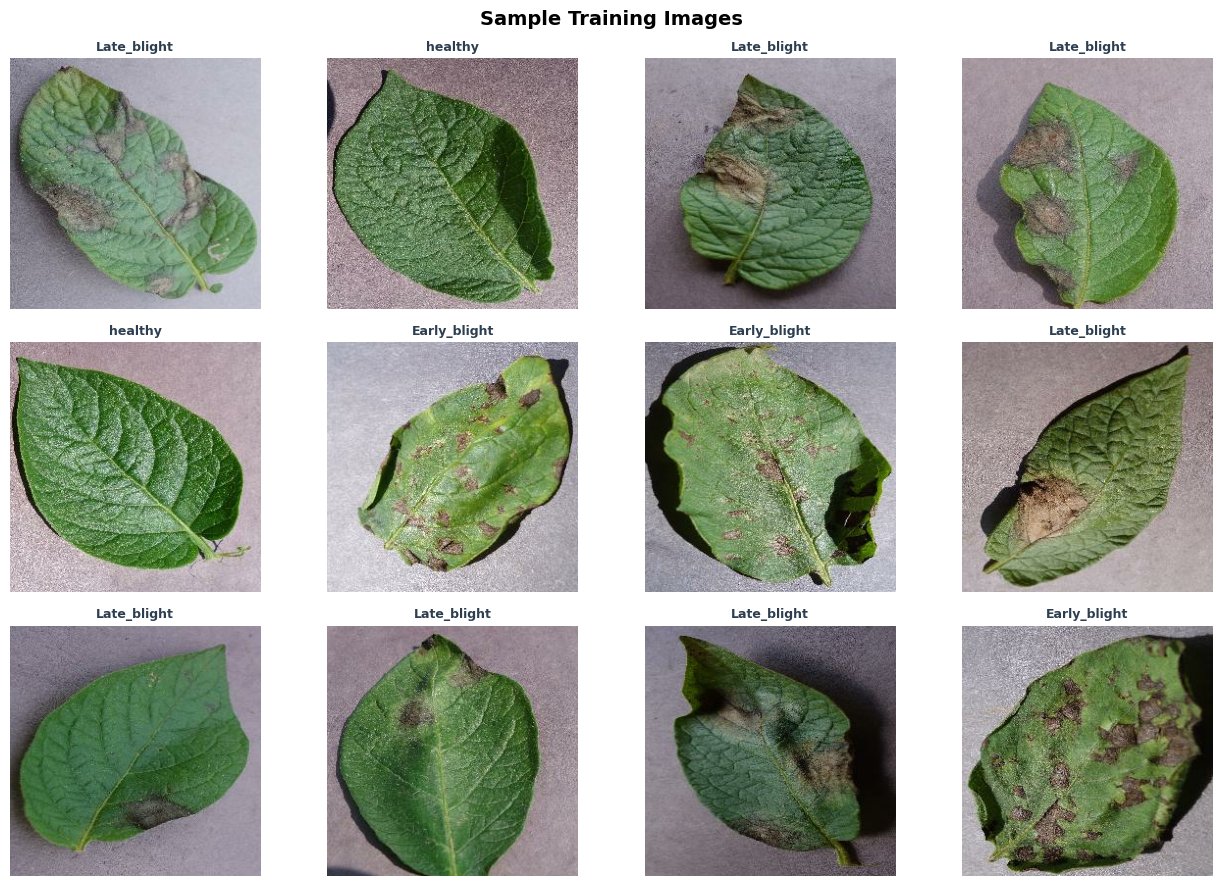

In [4]:
plt.figure(figsize=(13, 9))
for image_batch, label_batch in dataset.take(1):
    for i in range(min(12, image_batch.shape[0])):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        label_str = class_names[label_batch[i]].replace('Potato___', '')
        plt.title(label_str, fontsize=9, color='#2c3e50', fontweight='bold')
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Train / Validation / Test Split (80 / 10 / 10)

In [5]:
def split_dataset(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle_size=1000):
    assert abs(train_split + val_split + test_split - 1.0) < 1e-6, "Splits must sum to 1"
    ds_size = len(ds)
    ds = ds.shuffle(shuffle_size, seed=42)
    train_n = int(train_split * ds_size)
    val_n   = int(val_split   * ds_size)
    train_ds = ds.take(train_n)
    val_ds   = ds.skip(train_n).take(val_n)
    test_ds  = ds.skip(train_n + val_n)
    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = split_dataset(dataset)
print(f"Train : {len(train_ds)} batches (~{len(train_ds)*BATCH_SIZE} images)")
print(f"Val   : {len(val_ds)} batches (~{len(val_ds)*BATCH_SIZE} images)")
print(f"Test  : {len(test_ds)} batches (~{len(test_ds)*BATCH_SIZE} images)")

Train : 54 batches (~1728 images)
Val   : 6 batches (~192 images)
Test  : 8 batches (~256 images)


## 6. Performance Optimization (Cache + Prefetch)

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(500, seed=42).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("✅ Datasets optimized.")

✅ Datasets optimized.


## 7. Preprocessing + Data Augmentation

In [7]:
# Rescale pixel values [0, 255] → [0.0, 1.0]
rescaling = layers.Rescaling(1.0 / 255.0)

# Augmentation (only applied during training)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

print("✅ Preprocessing and augmentation layers ready.")

✅ Preprocessing and augmentation layers ready.


## 8. Build CNN Model (Keras 3 Compatible)

In [8]:
def build_model(image_size, channels, num_classes):
    inputs = keras.Input(shape=(image_size, image_size, channels), name="input_images")

    # Preprocessing
    x = rescaling(inputs)
    x = data_augmentation(x)

    # Conv Block 1
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Conv Block 2
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Conv Block 3
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Conv Block 4
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Conv Block 5
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Classifier Head
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="predictions")(x)

    return keras.Model(inputs, outputs, name="PDD_CNN")


model = build_model(IMAGE_SIZE, CHANNELS, NUM_CLASSES)
model.summary()

Model: "PDD_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_images (InputLayer)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,326,851 (5.06 MB)

 Trainable params: 1,326,851 (5.06 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Compile

In [9]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
print("✅ Model compiled.")

✅ Model compiled.


## 10. Callbacks

In [10]:
os.makedirs("./saved_models", exist_ok=True)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    # Save best model automatically
    keras.callbacks.ModelCheckpoint(
        filepath='./saved_models/pdd_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]
print("✅ Callbacks configured.")

✅ Callbacks configured.


## 11. Train the Model

In [11]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - accuracy: 0.4475 - loss: 1.0140
Epoch 1: val_accuracy improved from None to 0.59375, saving model to ./saved_models/pdd_best.keras

Epoch 1: finished saving model to ./saved_models/pdd_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 842ms/step - accuracy: 0.4900 - loss: 0.9475 - val_accuracy: 0.5938 - val_loss: 0.7926 - learning_rate: 0.0010
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 905ms/step - accuracy: 0.6985 - loss: 0.7141
Epoch 2: val_accuracy improved from 0.59375 to 0.85938, saving model to ./saved_models/pdd_best.keras

Epoch 2: finished saving model to ./saved_models/pdd_best.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 50s 926ms/step - accuracy: 0.7465 - loss: 0.6534 - val_accuracy: 0.8594 - val_loss: 0.4492 - learning_rate: 0.0010
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.8410 - loss: 0.4167
Epoch 3: val_accuracy did not improve from 0.85938
54/54 ━━━━━━━━━━━━━━━━━━━━ 43s 788ms/step - accuracy: 0.8462 - loss: 0.4001 

## 12. Evaluate on Test Set

In [12]:
results = model.evaluate(test_ds, verbose=1)
print(f"\n{'='*40}")
print(f"  Test Loss     : {results[0]:.4f}")
print(f"  Test Accuracy : {results[1]*100:.2f}%")
print(f"{'='*40}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.9453 - loss: 0.1294

  Test Loss     : 0.1294
  Test Accuracy : 94.53%


## 13. Plot Training History

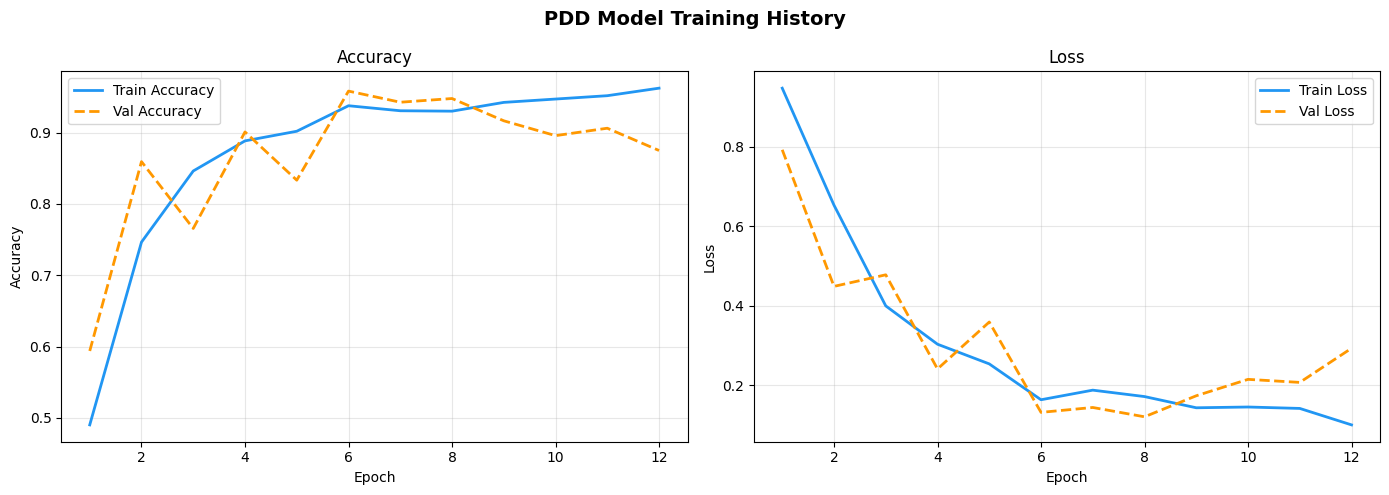

In [13]:
def plot_history(history):
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('PDD Model Training History', fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(epochs_range, acc,     label='Train Accuracy',  color='#2196F3', linewidth=2)
    axes[0].plot(epochs_range, val_acc, label='Val Accuracy',    color='#FF9800', linewidth=2, linestyle='--')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(epochs_range, loss,     label='Train Loss', color='#2196F3', linewidth=2)
    axes[1].plot(epochs_range, val_loss, label='Val Loss',   color='#FF9800', linewidth=2, linestyle='--')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history)

## 14. Predict on Test Batch

C:\Users\webco\AppData\Local\Temp\ipykernel_10700\2873745271.py:21: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\webco\AppData\Local\Temp\ipykernel_10700\2873745271.py:21: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\webco\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\webco\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


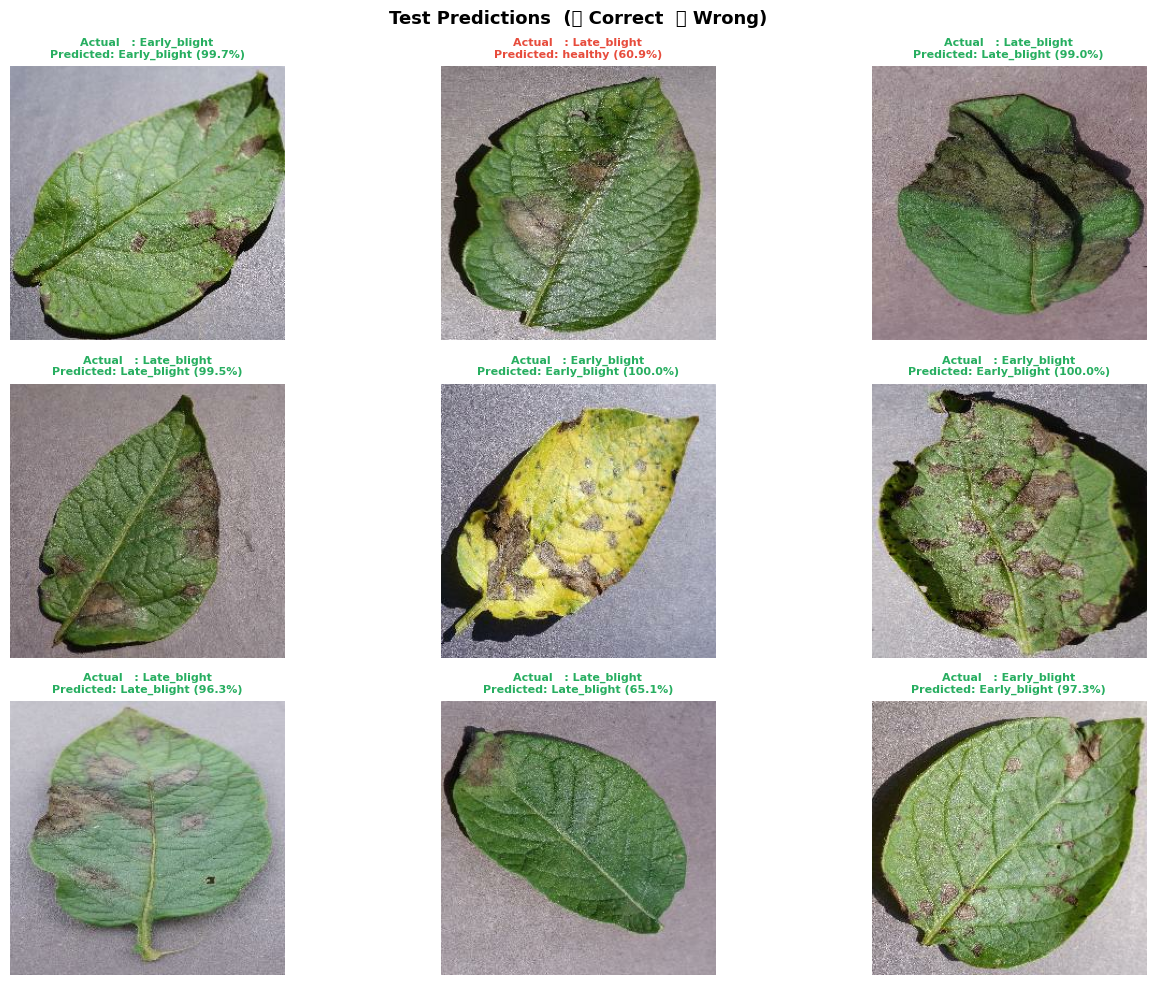

In [14]:
def predict_batch(model, dataset, class_names, n=9):
    plt.figure(figsize=(14, 10))
    for images, labels in dataset.take(1):
        preds = model.predict(images, verbose=0)
        for i in range(min(n, images.shape[0])):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype('uint8'))
            pred_idx   = np.argmax(preds[i])
            actual_idx = int(labels[i].numpy())
            confidence    = preds[i][pred_idx] * 100
            pred_label    = class_names[pred_idx].replace('Potato___', '')
            actual_label  = class_names[actual_idx].replace('Potato___', '')
            is_correct = (pred_idx == actual_idx)
            color = '#27ae60' if is_correct else '#e74c3c'
            plt.title(
                f"Actual   : {actual_label}\nPredicted: {pred_label} ({confidence:.1f}%)",
                color=color, fontsize=8, fontweight='bold'
            )
            plt.axis('off')
    plt.suptitle("Test Predictions  (🟢 Correct  🔴 Wrong)", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

predict_batch(model, test_ds, class_names)

## 15. Save Final Model
> **Keras 3 note:** Always save with `.keras` extension (native format). Avoid `.h5` for new code.

In [15]:
model_path = "./saved_models/pdd_model_v1.keras"
model.save(model_path)
print(f"✅ Model saved to: {os.path.abspath(model_path)}")
print(f"   File size: {os.path.getsize(model_path) / 1024 / 1024:.2f} MB")

✅ Model saved to: e:\Deep Learning\Z-Projects\PDD\saved_models\pdd_model_v1.keras
   File size: 15.26 MB


## 16. Load & Quick Verify

In [16]:
loaded_model = keras.models.load_model("./saved_models/pdd_model_v1.keras")

# Quick verification
scores = loaded_model.evaluate(test_ds, verbose=0)
print(f"✅ Loaded model test accuracy: {scores[1]*100:.2f}%")
print("   Model is ready for inference!")

✅ Loaded model test accuracy: 94.53%
   Model is ready for inference!
